In [152]:
import requests
from IPython.core.display import HTML
# HTML(f"""
# <style>
# @import "https://cdn.jsdelivr.net/npm/bulma@0.9.4/css/bulma.min.css";
# </style>
# """)

# Gradient image features: Histogram of Oriented Gradients (HoG) introduction

**Overview**
This exercise introduces image gradient extraction and demonstrates how to compute Histogram of Oriented Gradients (HoG) features on a sample image. The extracted HoG features will be used in later exercises for classification.


<article class="message">
    <div class="message-body">
        <strong>List of individual tasks</strong>
        <ul style="list-style: none;">
            <li>
            <a href="#descriptor">Task 1: Calculate the HoG descriptor</a>
            </li>
            <li>
            <a href="#test1">Task 2: Reflect</a>
            </li>
            <li>
            <a href="#test">Task 3: Visualizing and understanding the HoG de…</a>
            </li>
            <li>
            <a href="#test2">Task 4: Reflect</a>
            </li>
            <li>
            <a href="#compare_images">Task 5: Comparing HoG Features</a>
            </li>
            <li>
            <a href="#compare_images1">Task 6: Evaluating HoG Features</a>
            </li>
            <li>
            <a href="#interpretation">Task 7: Interpretation/ Understanding questions</a>
            </li>
            <li>
            <a href="#interpretation1">Task 8: Interpretation/ Understanding questions</a>
            </li>
        </ul>
    </div>
</article>

The cell below loads a sample image.


(480, 852, 3)


Text(0.5, 1.0, 'Input image')

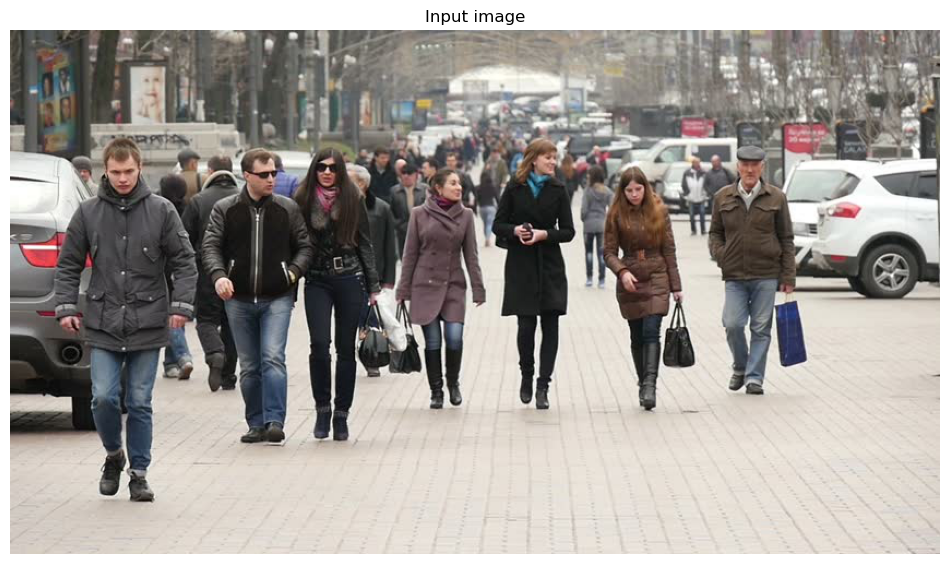

In [2]:
## load input image
import matplotlib.pyplot as plt
import numpy as np
from skimage.feature import hog
from skimage import data, exposure


fn =  "./data/people01.jpg"
image = plt.imread(fn)
print(image.shape)

fig, ax1 = plt.subplots(figsize=(12, 8), sharex=True, sharey=True)

ax1.axis('off')
ax1.imshow(image, cmap=plt.cm.gray)
ax1.set_title('Input image')

The following section: 
- Introduces the [HoG descriptor](https://en.wikipedia.org/wiki/Histogram_of_oriented_gradients)
- Shows how to calculate a HoG featues for an image including a visualization of the HoG descriptor.

## Overview of Histogram of Oriented Gradients (HoG) Algorithm
The Histogram of Oriented Gradients (HoG) is a feature descriptor used to detect objects in images. 
The function [skimage.feature.HoG](https://scikit-image.org/docs/stable/api/skimage.feature.html<elem-3>.feature.HoG) computes the HoG features. It also returns the feature descriptor vector (`fd`), in which its size is equal to the number of: Bins $\times$ Block Columns $\times$ Block Rows $\times$ Cells in the Block.

The process involves the following stages:


**1. Preprocessing / Smoothing:**

Initially, the image undergoes a global intensity normalization to diminish the effects of lighting. A common technique involves gamma (power-law) transformation of pixels, which can be achieved by calculating the square root or logarithm of each color channel. This stage helps in reducing the impact of local shadowing and highlights variations since the image texture strength is generally related to the local surface illumination.


**2. Calculation of Image Gradients:**

This stage focuses on computing image gradients. The standard procedure is to either convert the image to grayscale or use the most prominent color channel. 
**Info**
This step was implemented by us in the first part of the exercise.

 
**3. Creation of Cells and Calculation of normalized Histograms:**

The objective is to create an encoding of local gradients. This involves partitioning the image window into smaller spatial cells. Each cell creates a histogram of image gradient orientations and performs various steps to normalize intensities and histograms. 


**4. Compilation of Feature Vector:**

The HoG feature is constructed by concatenating the histograms for each cell into a combined vector. 

---
**Task 1 (easy): Calculate the HoG descriptor👩‍💻**
1. Run the cell below to calculate and plot the HoG descriptor. 


---

(270, 220, 3)


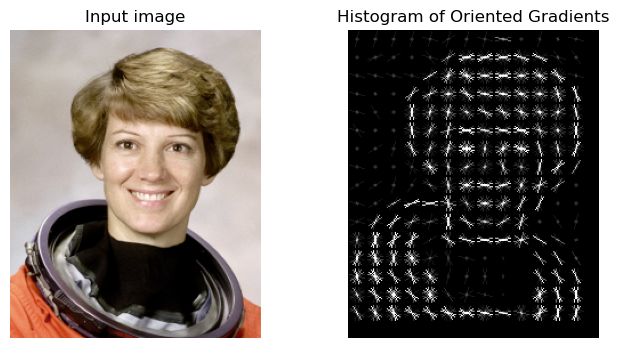

In [154]:
# load new image
image1 = data.astronaut()[:270,100:320]
print(image1.shape)

feature_vector=True,
bins = 8
pixels_per_cell = 16
cells_per_block = 4

(fd1, HoG_feat1) = hog(
    image1,
    orientations=bins,
    pixels_per_cell=(pixels_per_cell, pixels_per_cell),
    cells_per_block=(cells_per_block, cells_per_block),
    block_norm="L2",
    visualize=True,
    feature_vector=True,
    channel_axis=-1
)
HoG_feat1 = HoG_feat1.astype("uint8")


# after implementation of the HoG function, run the following plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)

ax1.axis('off')
ax1.imshow(image1, cmap=plt.cm.gray)
ax1.set_title('Input image')

# Rescale histogram for better display
HoG_image_rescaled = exposure.rescale_intensity(HoG_feat1, in_range=(0, 10))

ax2.axis('off')
ax2.imshow(HoG_image_rescaled, cmap=plt.cm.gray)
ax2.set_title('Histogram of Oriented Gradients')
plt.show()


---
**Task 2 (easy): Reflect💡**
1. What charaterizes the local histograms and the HoG feature combined?


---

In [155]:
#Write your reflections here..

# The local histograms in the HoG feature descriptor capture the distribution of gradient orientations within small regions (cells) of the image.
# By combining these local histograms across the entire image, the HoG feature provides a comprehensive representation of the object's shape and structure, making it effective for object detection tasks.


---
**Task 3 (easy): Visualizing and understanding the HoG descriptor👩‍💻**
Change the parameters of the HoG descriptor and visualize how the feature descriptor changes.
1. Change the parameters for the HoG descriptor:

- the number of bins
- the number of pixels per cell
- the number of cells per block

and visually observe how the dimensionality and the features change.

2. The following cell loads an image of a cat. Calculate the HoG descriptor of the cat image.


---

(270, 220, 3)


Text(0.5, 1.0, 'Histogram of Oriented Gradients')

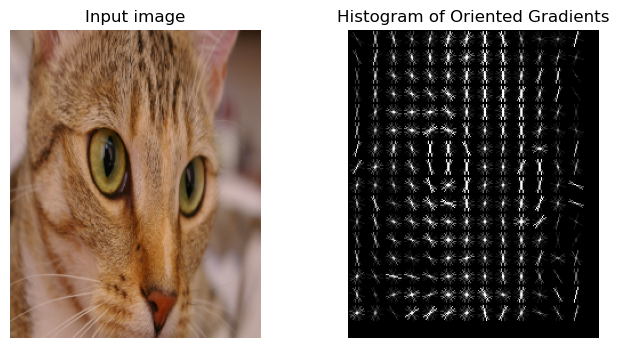

In [156]:
image2 = data.cat()[:270,:440:2]
print(image2.shape)

#fd2,HoG_image2 = image # replace this with HoG feature results. fd is the feature vector and HoG_image is the visualization of the calculated gradients.
fd2, HoG_feat2 = hog(
    image2,
    orientations=bins,
    pixels_per_cell=(pixels_per_cell, pixels_per_cell),
    cells_per_block=(cells_per_block, cells_per_block),
    block_norm="L2",
    visualize=True,
    feature_vector=True,
    channel_axis=-1
)
HoG_feat2 = HoG_feat2.astype("uint8")


# after implementation of the HoG function, run the following plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)

ax1.axis('off')
ax1.imshow(image2, cmap=plt.cm.gray)
ax1.set_title('Input image')

# Rescale histogram for better display
HoG_image_rescaled2 = exposure.rescale_intensity(HoG_feat2, in_range=(0, 10))

ax2.axis('off')
ax2.imshow(HoG_image_rescaled2, cmap=plt.cm.gray)
ax2.set_title('Histogram of Oriented Gradients')

In [157]:
#Changing the number of bins:
# The more bins you have, the more detailed the orientation representation will be, leading to a higher-dimensional feature vector.
# Fewer bins result in a coarser representation, reducing the dimensionality of the feature vector.
# Simply the number of bins determines how many different orientations the gradients can be classified into.

#Chaning the number of pixels per cell:
# Increasing the number of pixels per cell results in larger cells, which capture more spatial information and lead to a lower-dimensional feature vector.
# Decreasing the number of pixels per cell creates smaller cells, capturing finer details and increasing the dimensionality of the feature vector.
# The number of pixels per cell affects the spatial resolution of the HoG descriptor.
# It is important to choose an appropriate value based on the size of the objects being detected in the image, since too large or too small cells can lead to loss of important features.

#Changing the number of cells per block:
# At first, i did not see any changes when changing the number of cells per block.
# And i felt like it was kind of the same meaning as the number of pixels per cell.
# But after some thinking, I realized that the number of cells per block determines how many cells are grouped together for normalization.
# Increasing the number of cells per block leads to larger blocks, which can capture more contextual information and result in a lower-dimensional feature vector.
# Decreasing the number of cells per block creates smaller blocks, capturing finer details and increasing the dimensionality of the feature vector.
# In simple words, the difference is that the visual result changes when changing the number of pixels per cell, while the visual result does not change when changing the number of cells per block.
# This is because the number of pixels per cell affects the spatial resolution of the HoG descriptor, while the number of cells per block affects the normalization process without altering the spatial resolution directly.
# But does it even mean anything to change the number of cells per block then? Yes, it does, because it affects the normalization of the histograms, which can impact the robustness of the descriptor to changes in illumination and contrast.


---
**Task 4 (easy): Reflect💡**
1. What charaterizes the local histograms and the HoG feature combined?


---

In [158]:
#Write your reflections here...

# 1. What charaterizes the local histograms and the HoG feature combined?
# (Same answer as before)
# The local histograms in the HoG feature descriptor capture the distribution of gradient orientations within small regions (cells) of the image.
# By combining these local histograms across the entire image, the HoG feature provides a comprehensive representation of the object's shape and structure, making it effective for object detection tasks.



---
**Task 5 (easy): Comparing HoG Features👩‍💻**
This task is about comparing HoG features of two different images. 
1. Change the parameters of the HoG descriptor and visually compare the HoG features.
2. Calculate the normalized (use `np.linalg.norm`
 to normalize vectors) scalar product between the two feature vectors `fd1` and `fd2`.     
   - What is the scalar product between two feature vectors? (compare it to the value of 1 )
   - Repeat the calculation for multiple HoG filter parameters, and describe how these parameters influence the result. 



**Hint**
Set `feature_vector`
=True in `HoG`


3. Based on the cosine similarity (normalized inner product), explain how HoG features can be used to classify different images of cat/humans.


---

In [ ]:
#calculate the similarity here..

fd1_normalized = fd1 / np.linalg.norm(fd1)
fd2_normalized = fd2 / np.linalg.norm(fd2)
normalized_scalar_product = np.dot(fd1_normalized, fd2_normalized)
print("Feacture vector similarity:", normalized_scalar_product) 
print(f"With {bins} bins, {pixels_per_cell} pixels per cell, and {cells_per_block} cells per block.")

Feacture vector similarity: 0.4300893862777714
With 8 bins, 16 pixels per cell, and 4 cells per block.


In [ ]:
#Write your reflections here...

# #This task is about comparing HoG features of two different images. 
# 1. Change the parameters of the HoG descriptor and visually compare the HoG features.
# (Kind of same answer as before)
# The number of bins determines how many different orientations the gradients can be classified into.
# The more bins you have, the more detailed the orientation representation will be, leading to a higher-dimensional feature vector.
# Fewer bins result in a coarser representation, reducing the dimensionality of the feature vector.
# The number of pixels per cell affects the spatial resolution of the HoG descriptor.
# Increasing the number of pixels per cell results in larger cells, which capture more spatial information and lead to a lower-dimensional feature vector.
# Decreasing the number of pixels per cell creates smaller cells, capturing finer details and increasing the dimensionality of the feature vector.
# It is important to choose an appropriate value based on the size of the objects being detected in the image, since too large or too small cells can lead to loss of important features.
# The number of cells per block affects the normalization process without altering the spatial resolution directly.
# Increasing the number of cells per block leads to larger blocks, which can capture more contextual information and result in a lower-dimensional feature vector.
# Decreasing the number of cells per block creates smaller blocks, capturing finer details and increasing the dimensionality of the feature vector.
# The visual result changes when changing the number of pixels per cell, while the visual result does not change when changing the number of cells per block.
# This is because the number of pixels per cell affects the spatial resolution of the HoG descriptor, while the number of cells per block affects the normalization process.
# The number of cells per block impacts the robustness of the descriptor to changes in illumination and contrast.



# 2. Calculate the normalized (use `np.linalg.norm` to normalize vectors) scalar product between the two feature vectors `fd1` and `fd2`.     
# - What is the scalar product between two feature vectors? (compare it to the value of 1 )
# The scalar product between two normalized feature vectors indicates the similarity between the two images based on their HoG features. 
# A value close to 1 suggests high similarity, while a value closer to 0 indicates low similarity.

# - Repeat the calculation for multiple HoG filter parameters, and describe how these parameters influence the result. 

#Results:
# Feacture vector similarity: 0.4300893862777714
# With 8 bins, 16 pixels per cell, and 4 cells per block.

# Feacture vector similarity: 0.6979694892005842
# With 2 bins, 16 pixels per cell, and 4 cells per block.

# Feacture vector similarity: 0.41227660791422016
# With 10 bins, 16 pixels per cell, and 4 cells per block.

# Feacture vector similarity: 0.391865944694678
# With 8 bins, 10 pixels per cell, and 4 cells per block.

# Feacture vector similarity: 0.4755628958679441
# With 8 bins, 20 pixels per cell, and 4 cells per block.

# Feacture vector similarity: 0.526259339051082
# With 8 bins, 16 pixels per cell, and 2 cells per block.

# Feacture vector similarity: 0.4060514057490139
# With 8 bins, 16 pixels per cell, and 10 cells per block.

# Observations:
# - Changing the number of bins affects the level of detail in the orientation representation, which can influence the similarity score.
#   A higher number of bins may capture more nuanced differences between images, potentially lowering the similarity score, 
#   while fewer bins may lead to a higher similarity score due to a coarser representation.
# - Adjusting the number of pixels per cell impacts the spatial resolution of the HoG descriptor.
#   Smaller cells capture finer details, which may highlight differences between images and reduce the similarity score.
#   Larger cells capture broader features, potentially increasing the similarity score by overlooking finer distinctions.
# - Modifying the number of cells per block influences the normalization of the histograms.
#   Smaller blocks (less cells per block) may emphasize local variations, leading to a lower similarity score, 
#   while larger blocks provide more robust normalization, potentially increasing the similarity score.


# 3. Based on the cosine similarity (normalized inner product), explain how HoG features can be used to classify different images of cat/humans.
# cosine similarity = normalized inner product means that we are measuring the cosine of the angle between two vectors in a multi-dimensional space.
# This is because the cosine similarity quantifies how similar two vectors are in terms of their direction, regardless of their magnitude.
# In relation to HoG features, this means that we can compare the orientation and distribution of gradients in different images without being affected by the overall brightness or contrast of the images.
# In other words, we use HoG features (which are based on gradient orientations) to create a feature space where images can be compared based on their shape and structure rather than pixel intensity values.
# HoG features can be used to classify different images of cats and humans by capturing the distinctive shape and structure of each object through their gradient orientations.
# By computing the HoG features for a set of training images of cats and humans, we can create a feature space where each image is represented by its HoG descriptor (a vector describing its gradient orientation distribution instead of raw pixel values).
# During classification, we can compute the HoG features for a new image and compare it to the training set using the normalized inner product.
# A high similarity with cat images and a low similarity with human images would indicate that the new image is likely a cat, and vice versa.


---
**Task 6 (easy): Evaluating HoG Features💡**
This task will compare two HoG features of different images. 
1. What is the scalar product between two feature vectors? (compare it to the value of 1 )
2. Repeat the calculation for multiple HoG filter settings, notice a difference? 


**Hint**
Set `feature_vector`
=True in `HoG`


3. Based on the cosine similarity (normalized inner product), explain how HoG features can be used to classify different images of cat/humans.


---

In [ ]:
#Write your reflections here...
# Same as above.


---
**Task 7 (medium): Interpretation/ Understanding questions👩‍💻**
Select several images from the dataset (`peopleXY.jpg`
) and visually compare the HoG features of people and non-people images. 
1. Run the cell below to visualizes the HoG features


---

(480, 852, 3)
 HoG feature vector shape: (27, 50, 4, 4, 8)
 HoG feature vector shape after vectorization: (172800,)


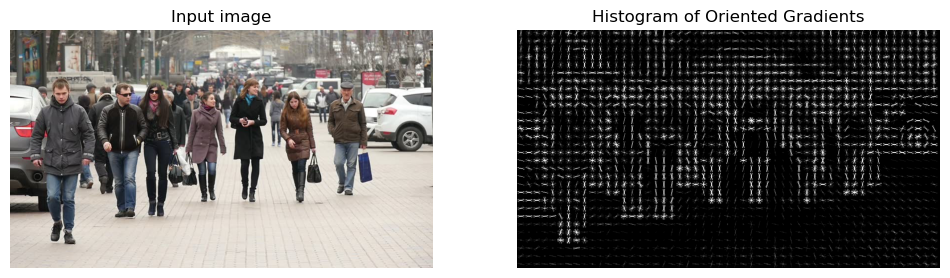

In [164]:
# load new image
fn =  "./data/people01.jpg"
image = plt.imread(fn)
print(image.shape)

feature_vector=True,
bins = 8 
pixels_per_cell = 16
cells_per_block = 4 

# Compute HoG.
(fd, HoG_feat) = hog(
    image,
    orientations=bins,
    pixels_per_cell=(pixels_per_cell, pixels_per_cell),
    cells_per_block=(cells_per_block, cells_per_block),
    block_norm="L2",
    visualize=True,
    feature_vector=False,
    channel_axis=-1
)
HoG_feat = HoG_feat.astype("uint8")


print(f' HoG feature vector shape: {fd.shape}')
print(f' HoG feature vector shape after vectorization: {fd.reshape(-1).shape}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)

ax1.axis('off')
ax1.imshow(image, cmap=plt.cm.gray)
ax1.set_title('Input image')

# Rescale histogram for better display
HoG_image_rescaled = exposure.rescale_intensity(HoG_feat, in_range=(0, 10))

ax2.axis('off')
ax2.imshow(HoG_image_rescaled, cmap=plt.cm.gray)
ax2.set_title('Histogram of Oriented Gradients')

plt.show()


---
**Task 8 (medium): Interpretation/ Understanding questions💡**
1. How could HoG features be used to classify different objects in a larger image with multiple people? 

2. Explain how the HoG features use local information to create an understanding of the content of the full image? 



---

In [ ]:
# write your reflections here

# 1. How could HoG features be used to classify different objects in a larger image with multiple people? 
# HoG features can be used to classify different objects in a larger image with multiple people by dividing the image into smaller regions (cells) and computing the HoG descriptor for each region.
# Each region's HoG features can then be compared to a database of known HoG features for different objects (e.g., faces, bodies, etc.).
# By analyzing the similarity between the HoG features of the regions and the known objects, we can classify and identify the different objects present in the larger image.

# 2. Explain how the HoG features use local information to create an understanding of the content of the full image? 
# The HoG features utilize local information by computing histograms of gradient orientations within small regions (cells) of the image.
# These local histograms capture the distribution of edge directions and intensities, which are indicative of the shapes and structures present in those regions.
# By aggregating these local histograms across the entire image, the HoG descriptor forms a comprehensive representation that reflects the overall content of the image.
# This allows the HoG features to effectively capture the spatial relationships and patterns that define the objects within the full image.
